In [1]:
import sys
sys.path.append('../')

import numpy as np
import torch
import matplotlib.pyplot as plt
from data_loader import PairData
from env_v2_06 import PairTradingEnv   # adds rolling HL as 5th state feature
from ddqn import DoubleDQN

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# ── Data & split ─────────────────────────────────────────────────────────
data   = PairData('../../data/real_pair_MCD_YUM.csv')
prices = data.s
N      = prices.shape[1]

train_end   = 3 * N // 4
PAST_WINDOW = 60
LOOKBACK    = 756   # 3-year estimation window for EMRT beta

log_A = np.log(prices[0])
log_B = np.log(prices[1])

print(f'N={N}  |  train [0, {train_end})  |  test [{train_end}, {N})')
print(f'LOOKBACK={LOOKBACK}  PAST_WINDOW={PAST_WINDOW}')

# ── EMRT beta selection ───────────────────────────────────────────────────
C_EMRT    = 1.0
BETA_GRID = np.arange(0.1, 3.01, 0.01)

def fit_window_emrt(t0, C=C_EMRT):
    A = log_A[t0 - LOOKBACK : t0]
    B = log_B[t0 - LOOKBACK : t0]
    K = len(BETA_GRID)

    Y_mat  = A[np.newaxis, :] - BETA_GRID[:, np.newaxis] * B[np.newaxis, :]
    stds   = Y_mat.std(axis=1, ddof=1)
    mus    = Y_mat.mean(axis=1)
    thresh = C * stds

    lmax = np.maximum.accumulate(Y_mat, axis=1)
    lmin = np.minimum.accumulate(Y_mat, axis=1)
    rmax = np.maximum.accumulate(Y_mat[:, ::-1], axis=1)[:, ::-1]
    rmin = np.minimum.accumulate(Y_mat[:, ::-1], axis=1)[:, ::-1]

    Ym  = Y_mat[:, 1:-1]
    imp = (
        ((Ym <= Y_mat[:, :-2]) & (Ym <= Y_mat[:, 2:]) &
         (lmax[:, :-2] - Ym >= thresh[:, None]) &
         (rmax[:, 2:]  - Ym >= thresh[:, None])) |
        ((Ym >= Y_mat[:, :-2]) & (Ym >= Y_mat[:, 2:]) &
         (Ym - lmin[:, :-2] >= thresh[:, None]) &
         (Ym - rmin[:, 2:]  >= thresh[:, None]))
    )

    emrts = np.full(K, np.inf)
    for k in range(K):
        if stds[k] < 1e-10:
            continue
        ext = np.where(imp[k])[0] + 1
        if len(ext) == 0:
            continue
        Y_k  = Y_mat[k]; mu_k = mus[k]
        taus = [int(ext[0])]; epos = 1
        while True:
            prev  = taus[-1]
            seg   = Y_k[prev:] - mu_k
            xings = np.where(seg[:-1] * seg[1:] <= 0)[0]
            if xings.size == 0:
                break
            cross = prev + int(xings[0]) + 1
            taus.append(cross)
            while epos < len(ext) and ext[epos] <= cross:
                epos += 1
            if epos >= len(ext):
                break
            taus.append(int(ext[epos])); epos += 1
        N_tau = len(taus)
        if N_tau >= 2:
            total   = sum(taus[i] - taus[i-1] for i in range(1, N_tau, 2))
            emrts[k] = (2.0 / N_tau) * total

    best_k = int(np.argmin(emrts))
    beta   = float(BETA_GRID[best_k])
    spread = A - beta * B
    icp    = float(np.mean(spread))
    return beta, icp

print('EMRT ready.')

N=5032  |  train [0, 3774)  |  test [3774, 5032)
LOOKBACK=756  PAST_WINDOW=60
EMRT ready.


In [3]:
# ── AR(1) and GBM helpers ─────────────────────────────────────────────────

def fit_ar1(series):
    y = series[1:]
    X = np.column_stack([np.ones(len(y)), series[:-1]])
    c, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return float(c[0]), float(c[1]), float(np.std(y - X @ c))

def fit_gbm(log_prices):
    r = np.diff(log_prices)
    return float(r.mean()), float(r.std(ddof=1))

print('AR(1) / GBM helpers ready.')

AR(1) / GBM helpers ready.


In [4]:
# ── Episode length ────────────────────────────────────────────────────────
EPISODE_LEN = 300
TOTAL_LEN   = PAST_WINDOW + 3 + EPISODE_LEN   # 363

print(f'EPISODE_LEN={EPISODE_LEN}  |  TOTAL_LEN={TOTAL_LEN}')

EPISODE_LEN=300  |  TOTAL_LEN=363


In [5]:
# ── Synthetic episode generator with per-window EMRT beta ────────────────
# 1. EMRT on [t0-LOOKBACK, t0) → beta, intercept
# 2. Fit AR(1) to that window's spread — use dynamics as-is (no HL override)
# 3. GBM for log_B
# 4. Simulate TOTAL_LEN bars

def gen_episode_emrt(t0):
    beta_ep, icp_ep = fit_window_emrt(t0)

    A_win      = log_A[t0 - LOOKBACK : t0]
    B_win      = log_B[t0 - LOOKBACK : t0]
    spread_win = A_win - beta_ep * B_win - icp_ep

    alpha_ep, phi_ep, sigma_ep = fit_ar1(spread_win)
    stat_mean_ep = alpha_ep / (1.0 - phi_ep)

    mu_B, sigma_B = fit_gbm(B_win)

    eps_s = rng.normal(0,    sigma_ep, TOTAL_LEN)
    eps_B = rng.normal(mu_B, sigma_B,  TOTAL_LEN)

    spread_sim    = np.empty(TOTAL_LEN)
    log_B_sim     = np.empty(TOTAL_LEN)
    spread_sim[0] = stat_mean_ep
    log_B_sim[0]  = B_win[-1]

    for t in range(1, TOTAL_LEN):
        spread_sim[t] = alpha_ep + phi_ep * spread_sim[t-1] + eps_s[t]
        log_B_sim[t]  = log_B_sim[t-1] + eps_B[t]

    log_A_sim  = spread_sim + beta_ep * log_B_sim + icp_ep
    syn_prices = np.exp(np.stack([log_A_sim, log_B_sim]))
    return syn_prices, beta_ep, icp_ep


# Sanity check
_t0 = LOOKBACK + 100
_p, _b, _icp = gen_episode_emrt(_t0)
_sp = np.log(_p[0]) - _b * np.log(_p[1]) - _icp
_hl = -np.log(2) / np.log(abs(np.corrcoef(_sp[:-1], _sp[1:])[0, 1]))
print(f't0={_t0}  beta={_b:.3f}  icp={_icp:.4f}')
print(f'Simulated spread  mean={_sp.mean():.4f}  std={_sp.std():.4f}  approx HL={_hl:.1f}d')

t0=856  beta=0.130  icp=3.1158
Simulated spread  mean=0.0273  std=0.0537  approx HL=21.1d


In [6]:
# ── Agent — state_dim=5 (z, pos, vel1, vel3, hl_norm) ────────────────────
agent = DoubleDQN(
    state_dim       = 5,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = 240_000,
    grad_clip       = 1.0,
)
print(f'Agent ready.  state_dim=5  Initial epsilon: {agent.epsilon:.3f}')

Agent ready.  state_dim=5  Initial epsilon: 1.000


In [7]:
# ── Training loop ─────────────────────────────────────────────────────────
N_EPISODES  = 1800
TRAIN_FREQ  = 4
LOG_EVERY   = 100

# Valid t0 range: need LOOKBACK bars before t0, episode ends within train set
T0_MIN = LOOKBACK
T0_MAX = train_end - 1

ep_rewards  = []
ep_wealth   = []
ep_eps      = []
ep_betas    = []
losses      = []
total_steps = 0

for ep in range(N_EPISODES):
    t0 = int(rng.integers(T0_MIN, T0_MAX + 1))
    prices_syn, beta_ep, icp_ep = gen_episode_emrt(t0)

    env = PairTradingEnv(
        prices_syn, beta=beta_ep, intercept=icp_ep,
        past_window=PAST_WINDOW, episode_len=EPISODE_LEN,
    )

    obs, _ = env.reset()
    done   = False
    ep_r   = 0.0

    while not done:
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.replay_buffer.add(obs, action, reward, next_obs, done)
        obs  = next_obs
        ep_r += reward
        total_steps += 1

        if total_steps % TRAIN_FREQ == 0:
            loss = agent.train()
            if loss is not None:
                losses.append(loss)

    ep_rewards.append(ep_r)
    ep_wealth.append(env._wealth())
    ep_eps.append(agent.epsilon)
    ep_betas.append(beta_ep)

    if (ep + 1) % LOG_EVERY == 0:
        avg_r = np.mean(ep_rewards[-LOG_EVERY:])
        avg_w = np.mean(ep_wealth[-LOG_EVERY:])
        avg_b = np.mean(ep_betas[-LOG_EVERY:])
        print(f'ep {ep+1:5d} | avg_reward {avg_r:+8.2f} | avg_wealth {avg_w:8.2f} | '
              f'eps {agent.epsilon:.3f} | avg_beta {avg_b:.3f}')

ep   100 | avg_reward  +168.58 | avg_wealth 10168.58 | eps 0.881 | avg_beta 1.332
ep   200 | avg_reward  +424.22 | avg_wealth 10424.22 | eps 0.762 | avg_beta 1.146
ep   300 | avg_reward  +647.07 | avg_wealth 10647.07 | eps 0.644 | avg_beta 1.176
ep   400 | avg_reward  +656.97 | avg_wealth 10656.97 | eps 0.525 | avg_beta 1.172
ep   500 | avg_reward  +804.57 | avg_wealth 10804.57 | eps 0.406 | avg_beta 1.206
ep   600 | avg_reward  +889.63 | avg_wealth 10889.63 | eps 0.287 | avg_beta 1.120
ep   700 | avg_reward  +795.73 | avg_wealth 10795.73 | eps 0.169 | avg_beta 1.246
ep   800 | avg_reward +1258.70 | avg_wealth 11258.70 | eps 0.050 | avg_beta 1.099
ep   900 | avg_reward +1453.45 | avg_wealth 11453.45 | eps 0.050 | avg_beta 1.190
ep  1000 | avg_reward +1389.60 | avg_wealth 11389.60 | eps 0.050 | avg_beta 1.193
ep  1100 | avg_reward +1326.07 | avg_wealth 11326.07 | eps 0.050 | avg_beta 1.111
ep  1200 | avg_reward +1084.35 | avg_wealth 11084.35 | eps 0.050 | avg_beta 1.100
ep  1300 | avg_r

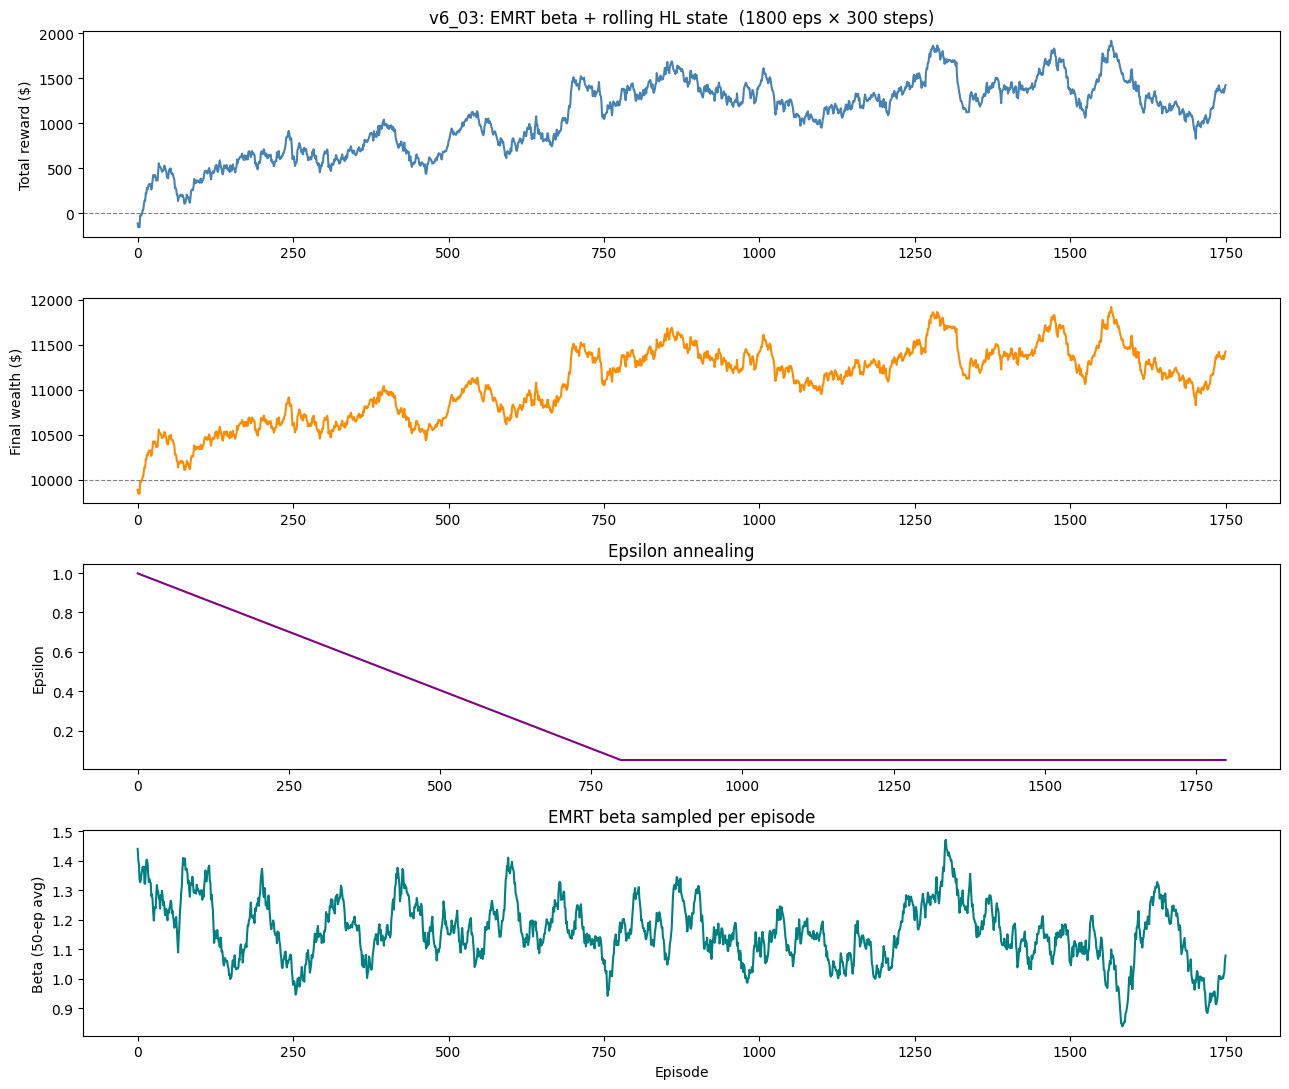

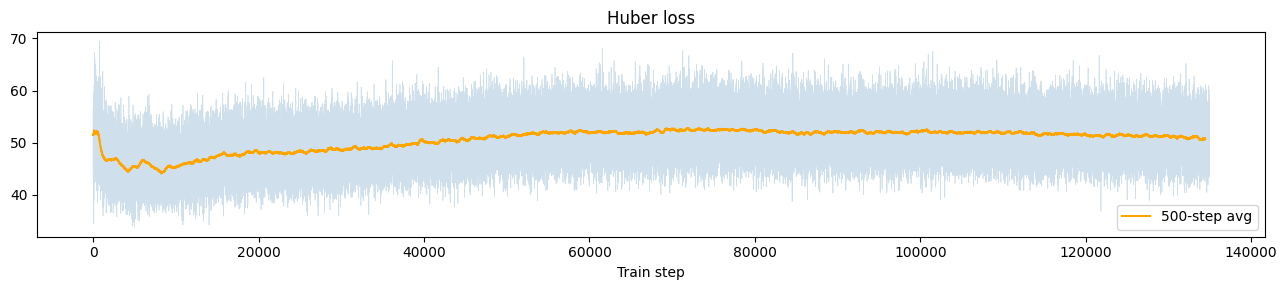

In [8]:
# ── Training curves ──────────────────────────────────────────────────────
roll = 50
kern = np.ones(roll) / roll

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=False)

axes[0].plot(np.convolve(ep_rewards, kern, mode='valid'), color='steelblue')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_ylabel('Total reward ($)')
axes[0].set_title(f'v6_03: EMRT beta + rolling HL state  '
                  f'({N_EPISODES} eps × {EPISODE_LEN} steps)')

axes[1].plot(np.convolve(ep_wealth, kern, mode='valid'), color='darkorange')
axes[1].axhline(10_000, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel('Final wealth ($)')

axes[2].plot(ep_eps, color='purple')
axes[2].set_ylabel('Epsilon')
axes[2].set_title('Epsilon annealing')

axes[3].plot(np.convolve(ep_betas, kern, mode='valid'), color='teal')
axes[3].set_ylabel(f'Beta ({roll}-ep avg)')
axes[3].set_xlabel('Episode')
axes[3].set_title('EMRT beta sampled per episode')

plt.tight_layout()
plt.show()

if losses:
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(losses, alpha=0.25, lw=0.5, color='steelblue')
    smooth = np.convolve(losses, np.ones(500)/500, mode='valid')
    ax.plot(smooth, color='orange', lw=1.5, label='500-step avg')
    ax.set_title('Huber loss')
    ax.set_xlabel('Train step')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [9]:
# ── Evaluation helpers ───────────────────────────────────────────────────

def evaluate(env, agent, t_start=None, t_end=None):
    if t_start is not None:
        env._t      = t_start
        env._end    = t_end if t_end is not None else env._N
        env._cash   = env.initial_wealth
        env._shares = np.zeros(2, dtype=np.float64)
        env._pos    = 0
        obs         = env._obs()
    else:
        obs, _ = env.reset()

    t0            = env._t
    wealth        = [env._wealth()]
    z_hist        = [float(obs[0])]
    hl_hist       = [float(obs[4]) * 252]   # convert hl_norm back to days
    pos_hist      = []
    entries_long  = []
    entries_short = []
    exits         = []
    step          = 0

    done = False
    while not done:
        prev_pos = env._pos
        action   = agent.select_action(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)

        pos_hist.append(env._pos)
        wealth.append(env._wealth())
        z_hist.append(float(obs[0]))
        hl_hist.append(float(obs[4]) * 252)

        if env._pos != prev_pos:
            if env._pos == 1:
                entries_long.append(step)
            elif env._pos == -1:
                entries_short.append(step)
            else:
                exits.append(step)
        step += 1

    return {
        'wealth':        np.array(wealth),
        'z':             np.array(z_hist),
        'hl':            np.array(hl_hist),
        'pos':           np.array(pos_hist),
        'entries_long':  entries_long,
        'entries_short': entries_short,
        'exits':         exits,
        't_start':       t0,
    }


def metrics(wealth, label=''):
    W   = np.array(wealth)
    ret = np.diff(W) / W[:-1]
    total_ret = (W[-1] / W[0] - 1.0) * 100
    sharpe    = ret.mean() / (ret.std() + 1e-10) * np.sqrt(252)
    peak      = np.maximum.accumulate(W)
    mdd       = ((W - peak) / peak).min() * 100
    print(f'{label:50s}  final ${W[-1]:8.0f}  ret {total_ret:+6.1f}%  Sharpe {sharpe:5.2f}  MDD {mdd:6.1f}%')
    return {'sharpe': sharpe, 'mdd': mdd, 'total_ret': total_ret}


_RF_DAILY = (1.05) ** (1.0 / 252) - 1

def plot_results(res, title=''):
    t0      = res['t_start']
    steps   = len(res['z']) - 1
    t_idx   = np.arange(t0, t0 + steps + 1)
    t_idx_p = t_idx[t_idx < prices.shape[1]]

    W         = res['wealth']
    benchmark = W[0] * (1 + _RF_DAILY) ** np.arange(len(W))

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(title, fontsize=12)

    axes[0].plot(t_idx, W,         color='navy', label='strategy')
    axes[0].plot(t_idx, benchmark, color='gray', lw=1, ls='--', label='5% p.a.')
    axes[0].axhline(W[0], color='lightgray', lw=0.6, ls=':')
    axes[0].set_ylabel('Wealth ($)')
    axes[0].legend(fontsize=8)

    axes[1].plot(t_idx_p, prices[0, t_idx_p], label=data.labels[0], alpha=0.8)
    axes[1].plot(t_idx_p, prices[1, t_idx_p], label=data.labels[1], alpha=0.8)
    axes[1].legend(fontsize=8)
    axes[1].set_ylabel('Price ($)')

    ax_z = axes[2]
    ax_z.plot(t_idx, res['z'], color='black', lw=0.8)
    ax_z.axhline(0,    color='gray',  lw=0.8, ls='--')
    ax_z.axhline( 2.0, color='green', lw=0.8, ls=':')
    ax_z.axhline(-2.0, color='green', lw=0.8, ls=':')
    pos_ext = np.concatenate([[0], res['pos']])
    for i in range(len(pos_ext) - 1):
        if pos_ext[i] == 1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='green')
        elif pos_ext[i] == -1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='red')
    for i in res['entries_long']:  ax_z.scatter(t_idx[i], res['z'][i], color='green', s=30, zorder=5)
    for i in res['entries_short']: ax_z.scatter(t_idx[i], res['z'][i], color='red',   s=30, zorder=5)
    for i in res['exits']:         ax_z.scatter(t_idx[i], res['z'][i], color='blue',  s=15, zorder=5)
    n_l = len(res['entries_long']);  n_s = len(res['entries_short'])
    ax_z.set_ylabel('Z-score')
    ax_z.set_title(f'long: {n_l}  |  short: {n_s}  |  exits: {len(res["exits"])}')

    axes[3].plot(t_idx, res['hl'], color='darkorange', lw=0.8)
    axes[3].axhline(20,  color='green', lw=0.8, ls=':', label='20d')
    axes[3].axhline(83,  color='gray',  lw=0.8, ls='--', label='83d (hist)')
    axes[3].axhline(150, color='red',   lw=0.8, ls=':', label='150d')
    axes[3].set_ylabel('Rolling HL (days)')
    axes[3].set_xlabel('Time index')
    axes[3].legend(fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.show()

=== Test set ===
EMRT beta at test start (t=3774): 0.4700  icp=3.0275
v6_03 (EMRT β=0.470) — test [3774–5032]             final $   13853  ret  +38.5%  Sharpe  0.77  MDD  -20.0%


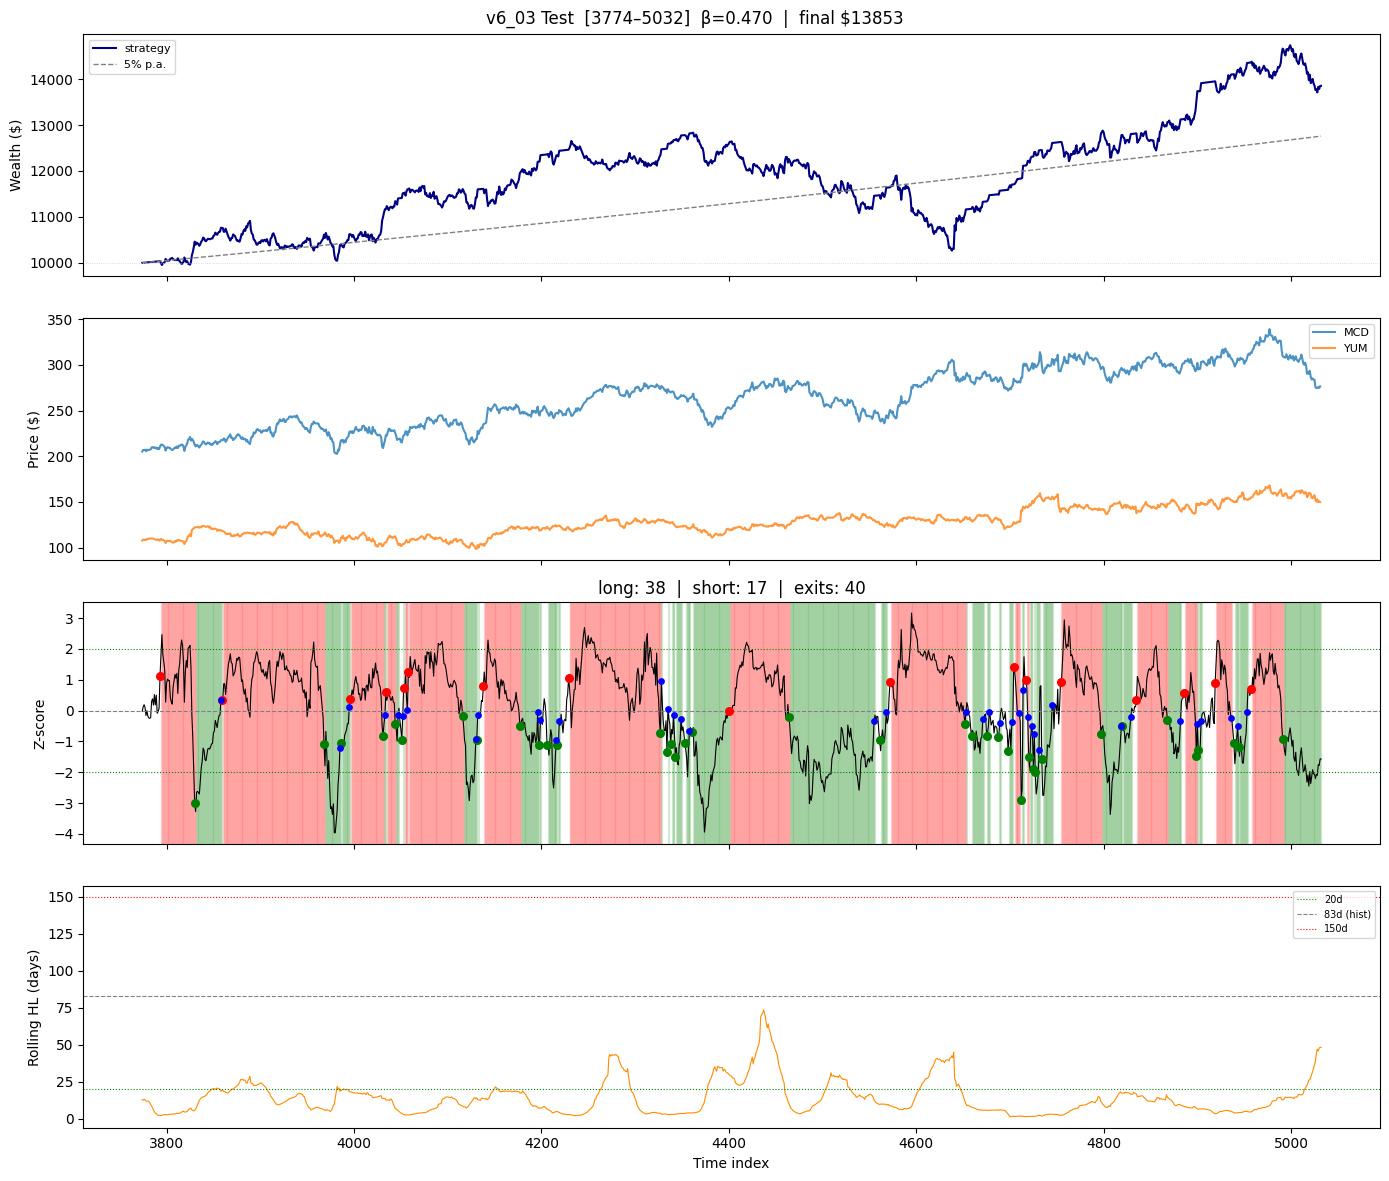

In [10]:
# ── Evaluation on real data — EMRT beta at each window start ─────────────
def make_real_env(t0, initial_wealth=10_000.0):
    beta_ev, icp_ev = fit_window_emrt(t0)
    env = PairTradingEnv(
        prices=prices, beta=beta_ev, intercept=icp_ev,
        past_window=PAST_WINDOW, initial_wealth=initial_wealth,
    )
    return env, beta_ev, icp_ev

print('=== Test set ===')
test_env, beta_test, icp_test = make_real_env(train_end)
print(f'EMRT beta at test start (t={train_end}): {beta_test:.4f}  icp={icp_test:.4f}')

res_test = evaluate(test_env, agent, t_start=train_end, t_end=N)
metrics(res_test['wealth'], f'v6_03 (EMRT β={beta_test:.3f}) — test [{train_end}–{N}]')
plot_results(res_test, title=f'v6_03 Test  [{train_end}–{N}]  β={beta_test:.3f}  |  '
             f'final ${res_test["wealth"][-1]:.0f}')

Test  [3774 – 5032]  (1258 days)
  Annualised return : +6.75%
  Sharpe ratio      : 0.767
  Max drawdown      : -20.0%


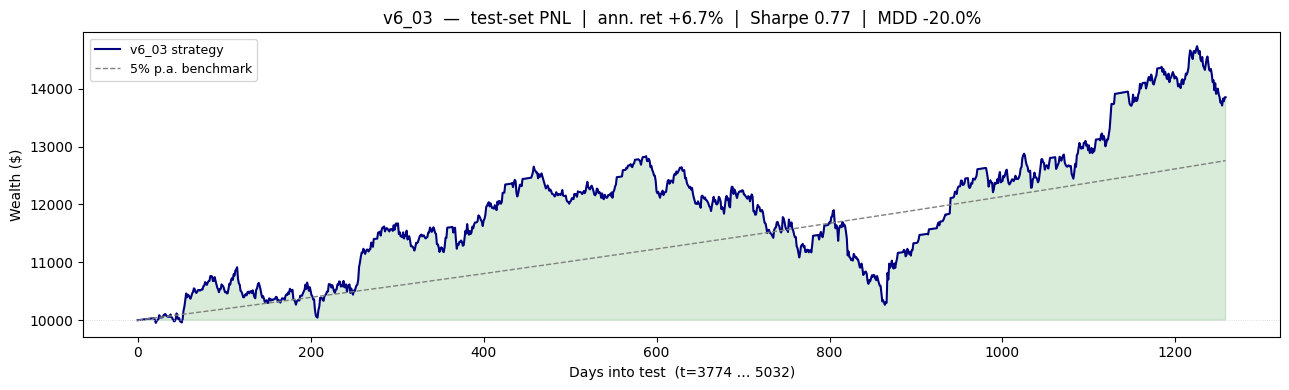

In [14]:
# ── Full test-set PNL ────────────────────────────────────────────────────
W   = res_test['wealth']
T   = len(W) - 1
ret = np.diff(W) / W[:-1]

ann_ret = (W[-1] / W[0]) ** (252.0 / T) - 1.0
sharpe  = ret.mean() / (ret.std() + 1e-10) * np.sqrt(252)
peak    = np.maximum.accumulate(W)
mdd     = ((W - peak) / peak).min() * 100

print(f'Test  [{train_end} – {N}]  ({T} days)')
print(f'  Annualised return : {ann_ret*100:+.2f}%')
print(f'  Sharpe ratio      : {sharpe:.3f}')
print(f'  Max drawdown      : {mdd:.1f}%')

fig, ax = plt.subplots(figsize=(13, 4))
t_axis  = np.arange(T + 1)
bm      = W[0] * (1 + _RF_DAILY) ** t_axis

ax.plot(t_axis, W,  color='navy', lw=1.5, label='v6_03 strategy')
ax.plot(t_axis, bm, color='gray', lw=1,   ls='--', label='5% p.a. benchmark')
ax.fill_between(t_axis, W, W[0], where=(W >= W[0]), alpha=0.15, color='green')
ax.fill_between(t_axis, W, W[0], where=(W <  W[0]), alpha=0.15, color='red')
ax.axhline(W[0], color='lightgray', lw=0.6, ls=':')

ax.set_title(
    f'v6_03  —  test-set PNL  |  ann. ret {ann_ret*100:+.1f}%  '
    f'|  Sharpe {sharpe:.2f}  |  MDD {mdd:.1f}%'
)
ax.set_ylabel('Wealth ($)')
ax.set_xlabel(f'Days into test  (t={train_end} … {N})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

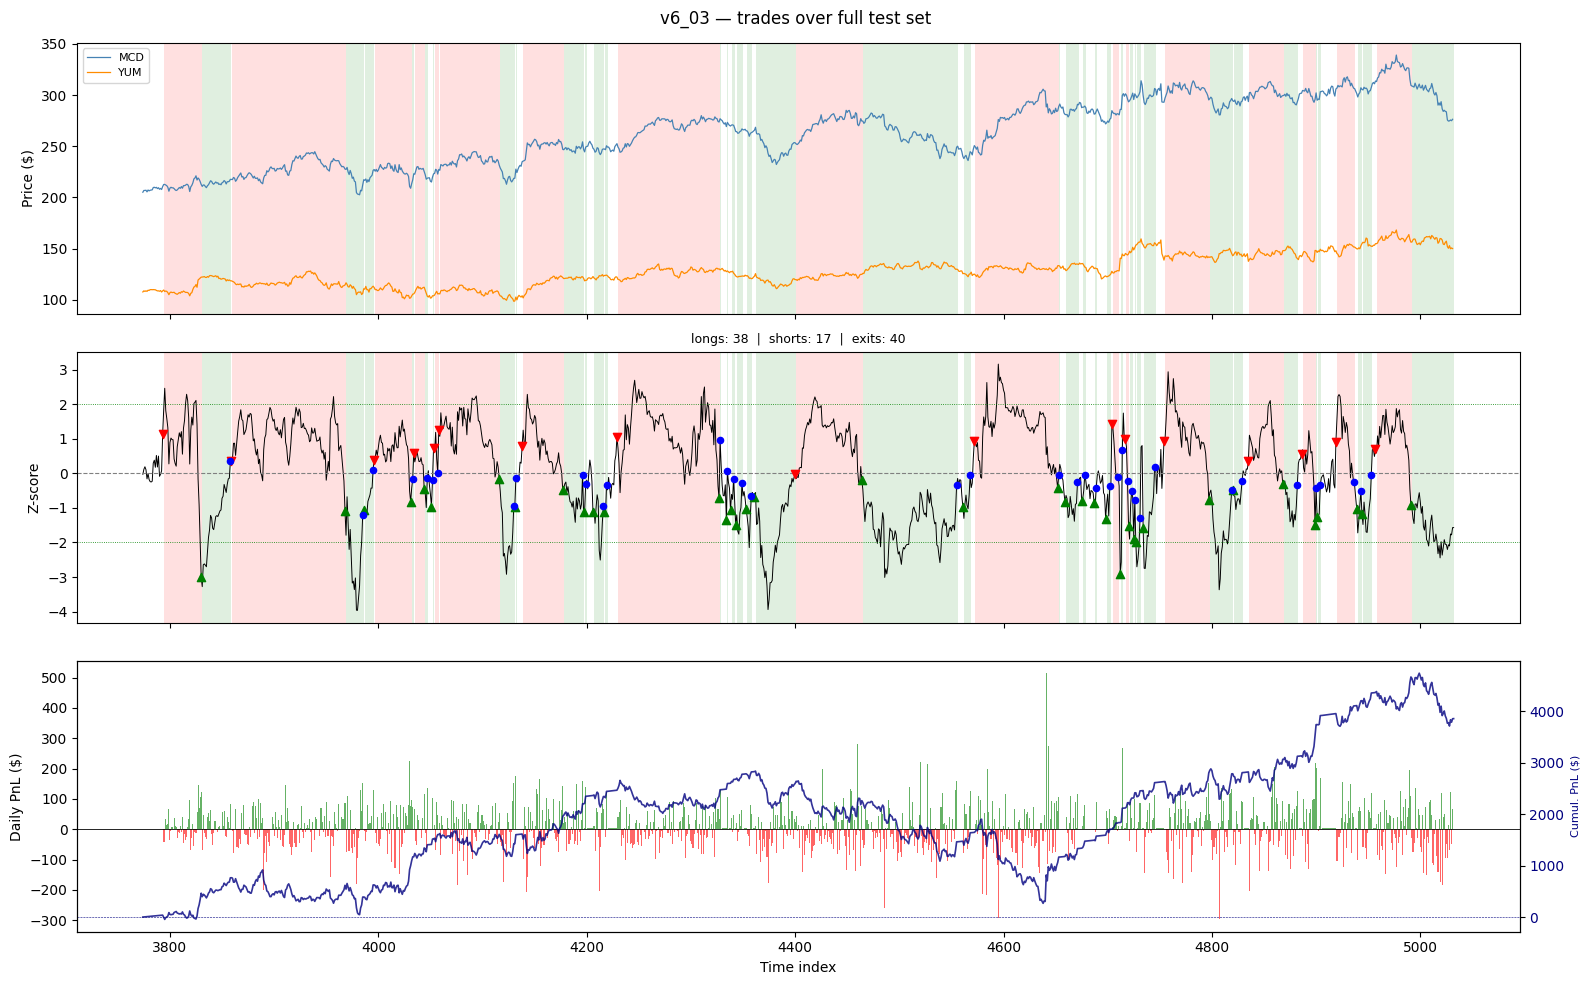

In [16]:
# ── Trade visualisation — full test set ──────────────────────────────────
t0    = res_test['t_start']
T     = len(res_test['z']) - 1
t_idx = np.arange(t0, t0 + T + 1)
t_idx_p = t_idx[t_idx < prices.shape[1]]   # safe slice for price array

W       = res_test['wealth']
z       = res_test['z']
pos_ext = np.concatenate([[0], res_test['pos']])   # len = T+1, aligned with t_idx

# Daily PnL for bar chart
daily_pnl = np.diff(W)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('v6_03 — trades over full test set', fontsize=12)

# ── Panel 1: prices with position shading ────────────────────────────────
ax = axes[0]
ax.plot(t_idx_p, prices[0, t_idx_p], label=data.labels[0], lw=0.9, color='steelblue')
ax.plot(t_idx_p, prices[1, t_idx_p], label=data.labels[1], lw=0.9, color='darkorange')
for i in range(T):
    if pos_ext[i] == 1:
        ax.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='green', lw=0)
    elif pos_ext[i] == -1:
        ax.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='red',   lw=0)
ax.set_ylabel('Price ($)')
ax.legend(fontsize=8, loc='upper left')

# ── Panel 2: z-score with trade markers ──────────────────────────────────
ax = axes[1]
ax.plot(t_idx, z, color='black', lw=0.7)
ax.axhline(0,    color='gray',  lw=0.8, ls='--')
ax.axhline( 2.0, color='green', lw=0.6, ls=':')
ax.axhline(-2.0, color='green', lw=0.6, ls=':')
for i in range(T):
    if pos_ext[i] == 1:
        ax.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='green', lw=0)
    elif pos_ext[i] == -1:
        ax.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='red',   lw=0)
for i in res_test['entries_long']:
    ax.scatter(t_idx[i], z[i], color='green', s=35, zorder=5, marker='^')
for i in res_test['entries_short']:
    ax.scatter(t_idx[i], z[i], color='red',   s=35, zorder=5, marker='v')
for i in res_test['exits']:
    ax.scatter(t_idx[i], z[i], color='blue',  s=20, zorder=5, marker='o')
ax.set_ylabel('Z-score')
n_l = len(res_test['entries_long']); n_s = len(res_test['entries_short'])
ax.set_title(f'longs: {n_l}  |  shorts: {n_s}  |  exits: {len(res_test["exits"])}',
             fontsize=9)

# ── Panel 3: daily PnL bars ──────────────────────────────────────────────
ax = axes[2]
colors = np.where(daily_pnl >= 0, 'green', 'red')
ax.bar(t_idx[1:], daily_pnl, color=colors, alpha=0.6, width=1.0)
ax.axhline(0, color='black', lw=0.6)

ax2 = ax.twinx()
ax2.plot(t_idx, W - W[0], color='navy', lw=1.2, alpha=0.8, label='cumulative PnL')
ax2.axhline(0, color='navy', lw=0.4, ls='--')
ax2.set_ylabel('Cumul. PnL ($)', color='navy', fontsize=8)
ax2.tick_params(axis='y', labelcolor='navy')

ax.set_ylabel('Daily PnL ($)')
ax.set_xlabel('Time index')

plt.tight_layout()
plt.show()

=== Training windows ===
Train yr 1  [756–1008]  β=0.580                     final $   12238  ret  +22.4%  Sharpe  2.20  MDD   -7.1%


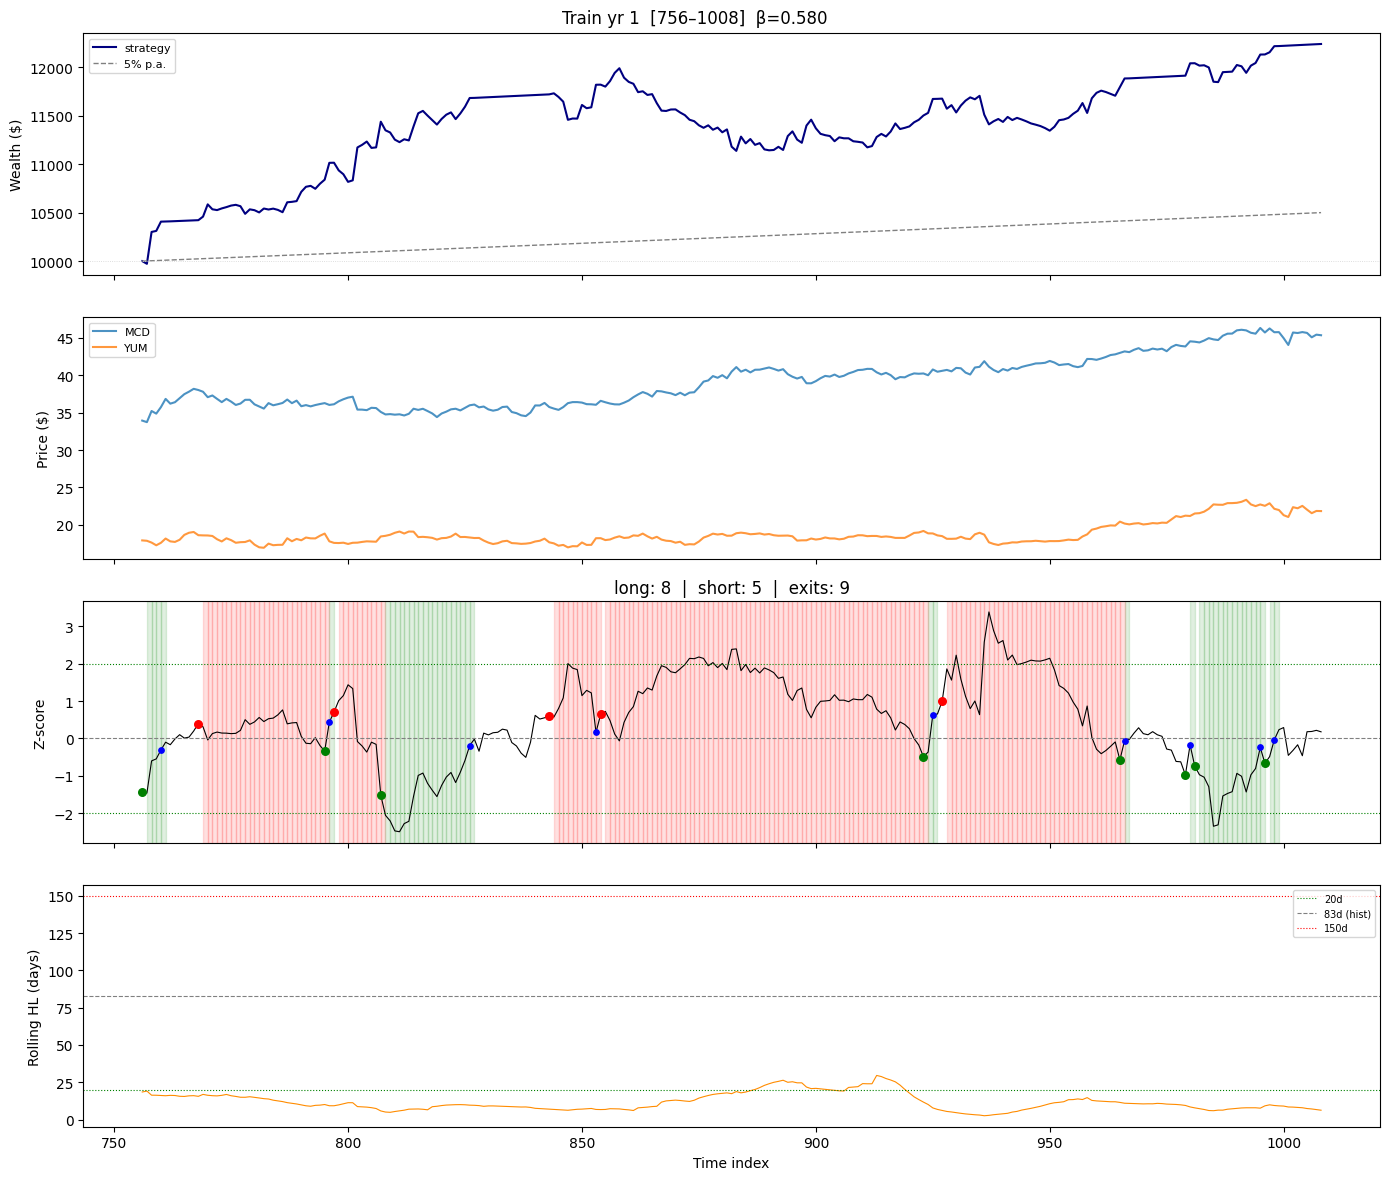

Train yr 2  [1008–1260]  β=0.140                    final $   10873  ret   +8.7%  Sharpe  0.78  MDD   -9.2%


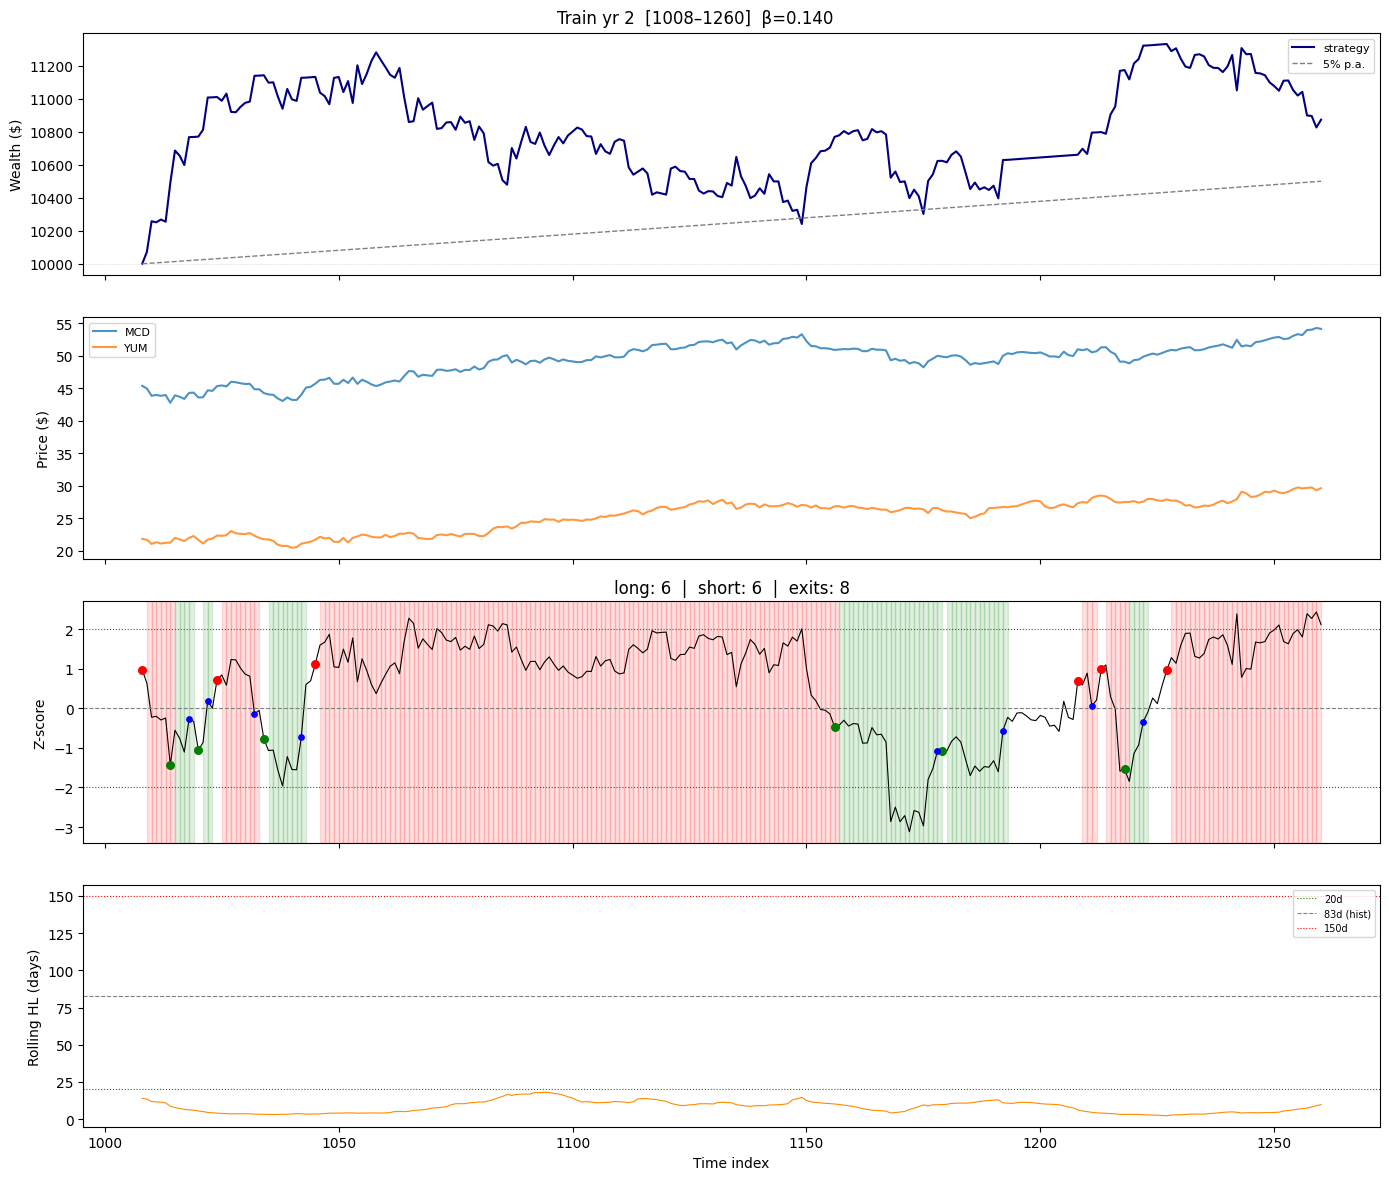

Train yr 3  [1260–1512]  β=1.370                    final $    9394  ret   -6.1%  Sharpe -0.50  MDD  -16.0%


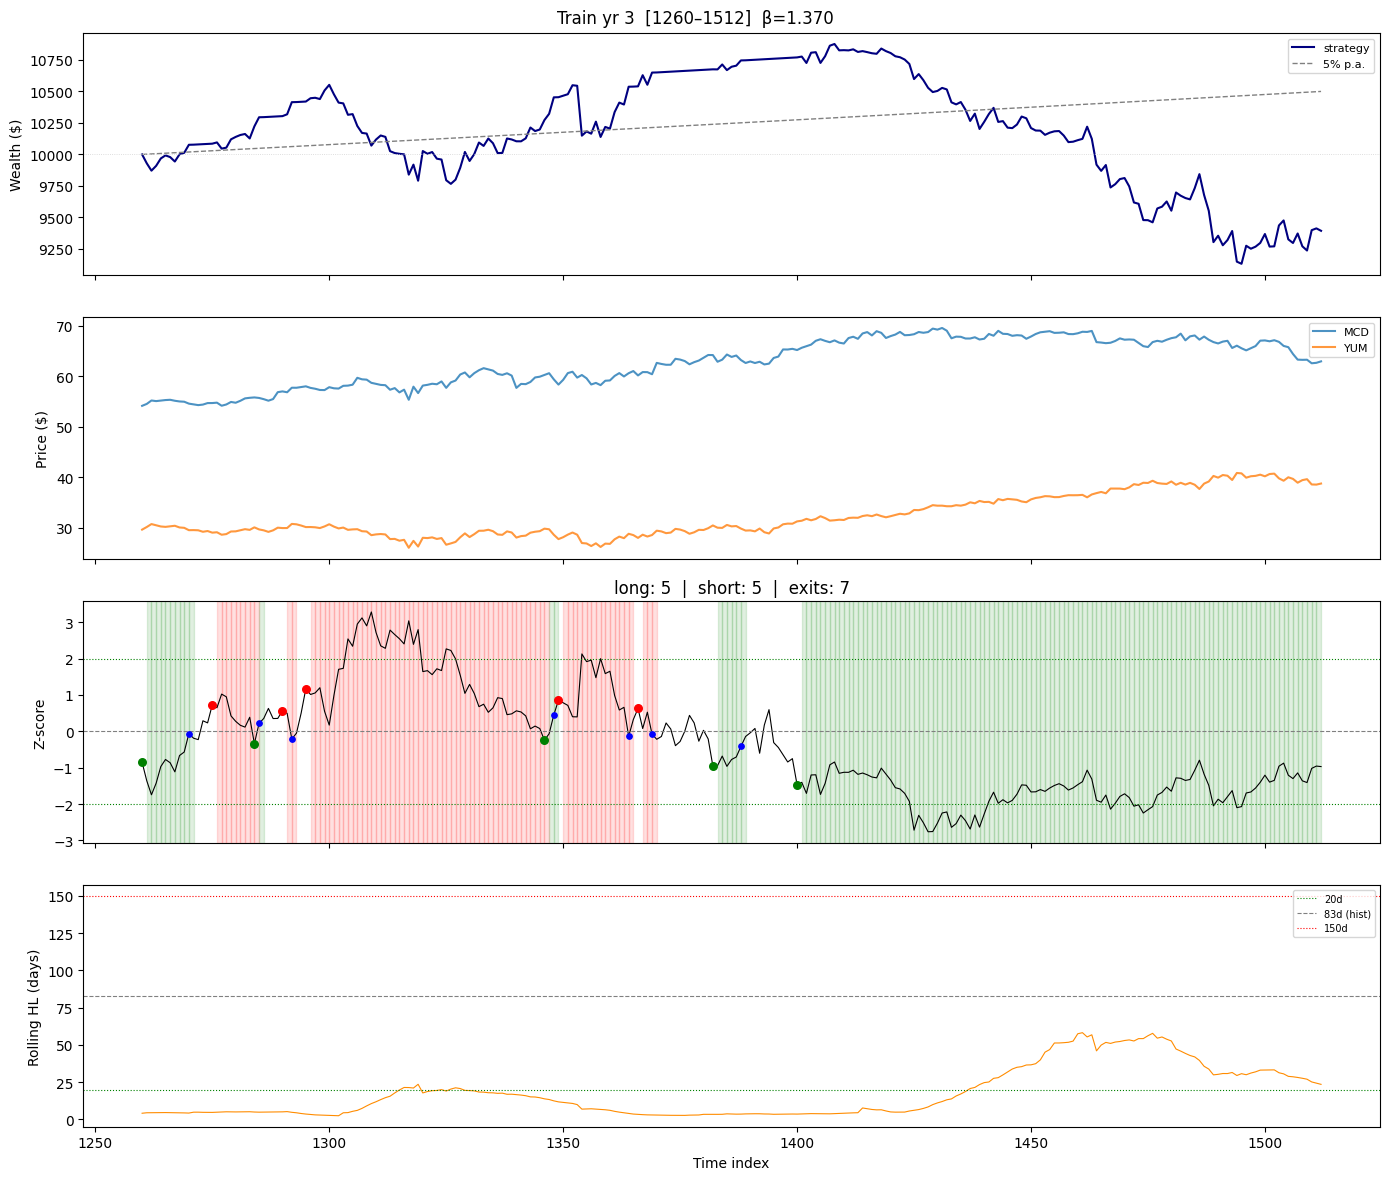

Train yr 4  [1512–1764]  β=0.720                    final $   11007  ret  +10.1%  Sharpe  0.93  MDD   -8.8%


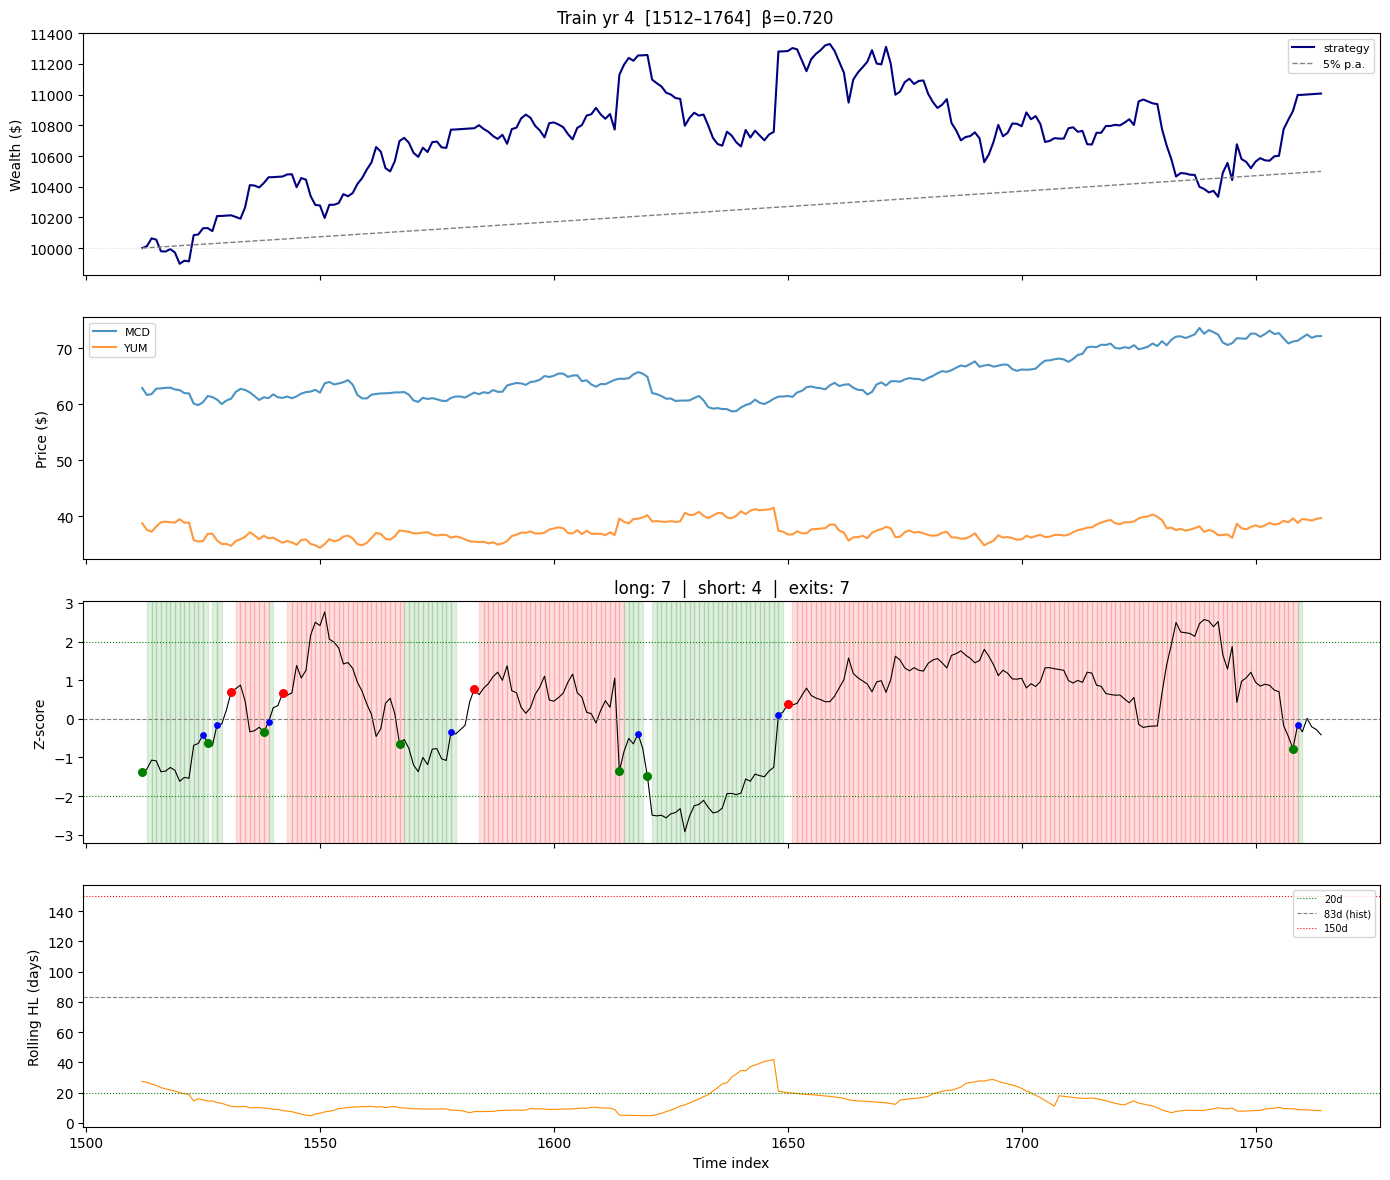

In [11]:
# ── Behaviour on training windows (per-window EMRT beta) ─────────────────
print('=== Training windows ===')
win = 252
t0_start = LOOKBACK

for k in range(4):
    t0 = t0_start + k * win
    t1 = t0 + win
    if t1 > train_end:
        break
    env_tr, beta_tr, icp_tr = make_real_env(t0)
    res_tr = evaluate(env_tr, agent, t_start=t0, t_end=t1)
    label  = f'Train yr {k+1}  [{t0}–{t1}]  β={beta_tr:.3f}'
    metrics(res_tr['wealth'], label)
    plot_results(res_tr, title=label)

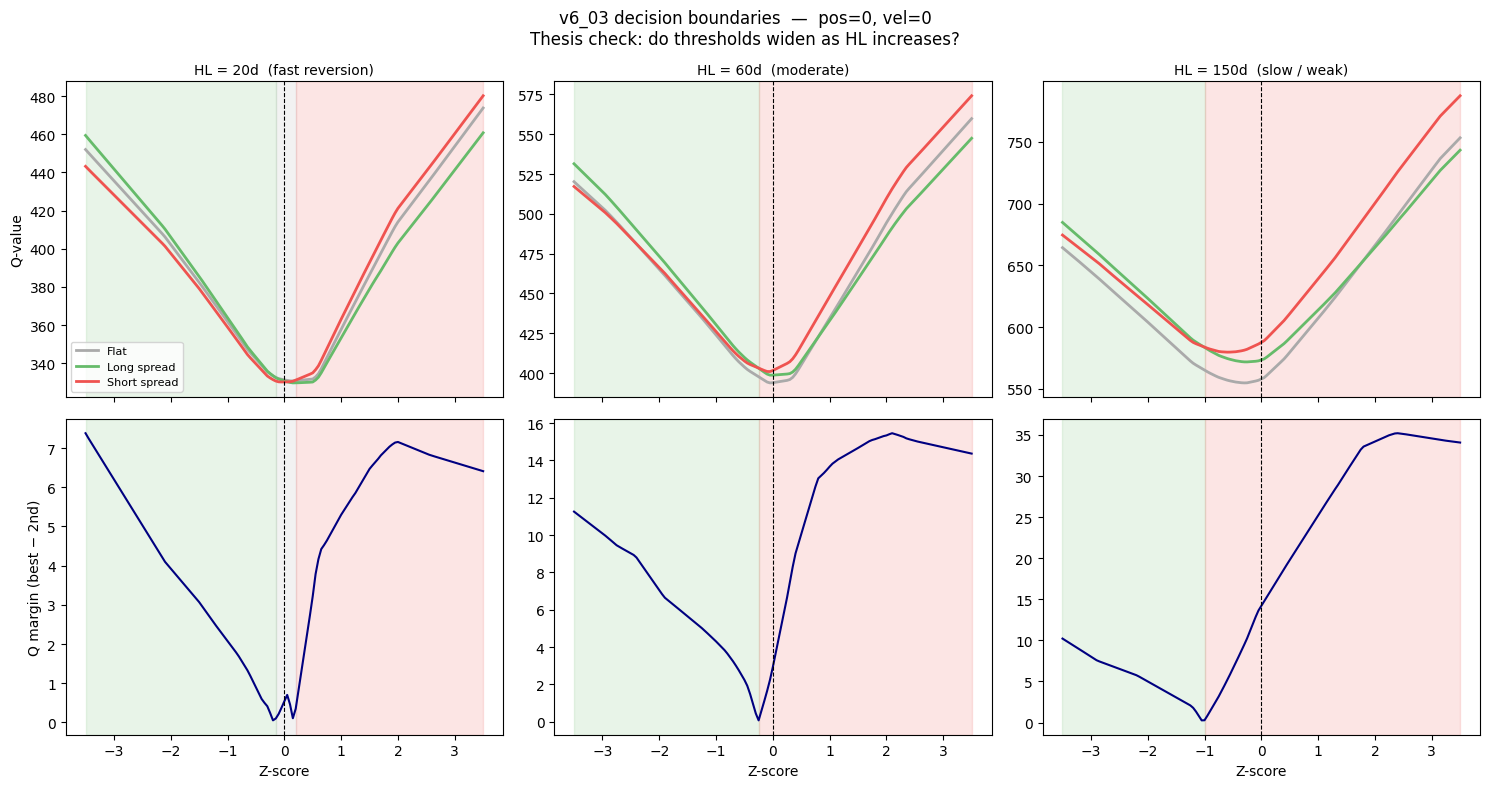


Entry thresholds by HL regime (pos=0, vel=0):
  HL = 20d  (fast re: z=-0.15 Long spread→Flat  z=+0.20 Flat→Short spread  
  HL = 60d  (moderat: z=-0.25 Long spread→Short spread  
  HL = 150d  (slow /: z=-1.00 Long spread→Short spread  


QNet(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [12]:
# ── Decision boundaries — does the agent condition on rolling HL? ─────────
# State: [z, pos, vel1, vel3, hl_norm]
# Fix pos=0, vel1=0, vel3=0 and sweep z across 3 HL regimes.
# If the agent learned to use HL, thresholds should tighten as HL drops.

ACT_LABELS = ['Flat', 'Long spread', 'Short spread']
ACT_COLORS = ['#aaaaaa', '#66bb6a', '#ef5350']

z_vals = np.linspace(-3.5, 3.5, 141)

# HL regimes: 20d (fast), 60d (moderate), 150d (slow)
hl_regimes = [
    (20  / 252, 'HL = 20d  (fast reversion)'),
    (60  / 252, 'HL = 60d  (moderate)'),
    (150 / 252, 'HL = 150d  (slow / weak)'),
]

agent.q_net.eval()
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
fig.suptitle('v6_03 decision boundaries  —  pos=0, vel=0\n'
             'Thesis check: do thresholds widen as HL increases?', fontsize=12)

for col, (hl_norm, hl_label) in enumerate(hl_regimes):
    q_vals = np.zeros((len(z_vals), 3))
    with torch.no_grad():
        for j, z in enumerate(z_vals):
            obs = torch.tensor([z, 0.0, 0.0, 0.0, hl_norm], dtype=torch.float32).unsqueeze(0)
            q_vals[j] = agent.q_net(obs).numpy()[0]

    best_act = q_vals.argmax(axis=1)

    ax_q = axes[0, col]
    ax_m = axes[1, col]

    # Background shading by preferred action
    prev_a = best_act[0]; seg_start = z_vals[0]
    for j in range(1, len(z_vals)):
        if best_act[j] != prev_a or j == len(z_vals) - 1:
            ax_q.axvspan(seg_start, z_vals[j], alpha=0.15, color=ACT_COLORS[prev_a])
            ax_m.axvspan(seg_start, z_vals[j], alpha=0.15, color=ACT_COLORS[prev_a])
            seg_start = z_vals[j]; prev_a = best_act[j]

    for a in range(3):
        ax_q.plot(z_vals, q_vals[:, a], color=ACT_COLORS[a], lw=2, label=ACT_LABELS[a])
    ax_q.axvline(0, color='black', lw=0.8, ls='--')
    ax_q.set_title(hl_label, fontsize=10)
    ax_q.set_ylabel('Q-value' if col == 0 else '')
    if col == 0:
        ax_q.legend(fontsize=8)

    sorted_q = np.sort(q_vals, axis=1)
    margin   = sorted_q[:, -1] - sorted_q[:, -2]
    ax_m.plot(z_vals, margin, color='navy', lw=1.5)
    ax_m.axvline(0, color='black', lw=0.8, ls='--')
    ax_m.set_xlabel('Z-score')
    ax_m.set_ylabel('Q margin (best − 2nd)' if col == 0 else '')

agent.q_net.train()
plt.tight_layout()
plt.show()

# Print thresholds
print('\nEntry thresholds by HL regime (pos=0, vel=0):')
agent.q_net.eval()
for hl_norm, hl_label in hl_regimes:
    with torch.no_grad():
        acts = [int(agent.q_net(torch.tensor([[z, 0., 0., 0., hl_norm]],
                dtype=torch.float32)).argmax()) for z in z_vals]
    changes = [(z_vals[j], acts[j-1], acts[j])
               for j in range(1, len(z_vals)) if acts[j] != acts[j-1]]
    print(f'  {hl_label[:18]:18s}: ', end='')
    for z, a_from, a_to in changes:
        print(f'z={z:+.2f} {ACT_LABELS[a_from]}→{ACT_LABELS[a_to]}  ', end='')
    print()
agent.q_net.train()

In [13]:
import os
os.makedirs('../models', exist_ok=True)
agent.save('../models/mcd_yum_ddqn_v6_03.pt')
print('Model saved.')

Model saved.
